# Méthode de Monte Carlo

Tout d'abord, on illustre numériquement les deux résultats probabilistes sur lesquels reposent la méthode dite de Monte Carlo: 

- la loi forte de grands nombres,
- le théorème central limit (TCL).

On considère ensuite un premier exemple d'estimateur de Monte Carlo et l'importance de l'intervalle de confiance (IC) dans lequel se trouve la valeur recherchée avec probabilité grande (0.95). 

Enfin on applique la méthode de Monte Carlo à un exemple multidimensionnel où on illustre l'efficacité de 2 méthodes de réduction de variance: 

- variables antithétiques, 
- variable de contrôle. 

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme() 
from numpy.random import default_rng
rng = default_rng()

## Illustration de la loi des grands nombres

Soit $(X_n)_{n \ge 1}$ une suite de variables aléatoires _i.i.d._ de carré intégrable. On définit les suites $(m_n)_{n \ge 1}$ et $(\sigma_n^2)_{n \ge 2}$ (non définie pour $n = 1$) de la façon suivante

$$
  m_n = \frac{1}{n} \sum_{k=1}^n X_k \qquad \text{et} \qquad 
  \sigma_n^2 = \frac{1}{n-1} \sum_{k=1}^n (X_k - m_n)^2 \quad \text{pour} \; n \ge 2
$$
et on veut illustrer la Loi Forte des Grands Nombres et le Théorème Central Limite (étendu en utilisant le lemme de Slutsky pour remplacer $\sigma^2 = \mathrm{var}(X_1)$ par l'estimateur $\sigma_n^2$) c'est à dire les convergences

$$
  m_n \xrightarrow{p.s.} m \qquad \text{et} \qquad 
  \sqrt{n} \Bigl(\frac{m_n - m}{\sigma_n}\Bigr) \xrightarrow{\mathcal{L}} \mathcal{N}(0, 1).
$$

Plus précisément on construit l'intervalle de confiance (asymptotique) à 95% à partir du TCL c'est à dire

$$
  \text{pour $n$ grand} \quad \mathbf{P} \biggl( m \in 
  \biggl[
    m_n - \frac{1.96 \sigma_n}{\sqrt{n}}, 
    m_n + \frac{1.96 \sigma_n}{\sqrt{n}}
  \biggr] \biggr) \simeq 0.95
$$

### Question: LFGN loi uniforme

Reproduire le tracé suivant où les points (les croix 'x') sont les réalisations $X_n$ (en fonction de $n$) de loi uniforme sur $[-4,8]$. La ligne bleue (couleur 'C0', première couleur de la palette utilisée) correspond à la moyenne $m$, la courbe orangée (couleur 'C1') correspond à la suite $m_n$ et les lignes grises correspondent aux bornes de l'intervalle de confiance. La zone de confiance en jaune s'obtient par la méthode `fill_between` de `ax`.

![](img/tcl_unif.png)

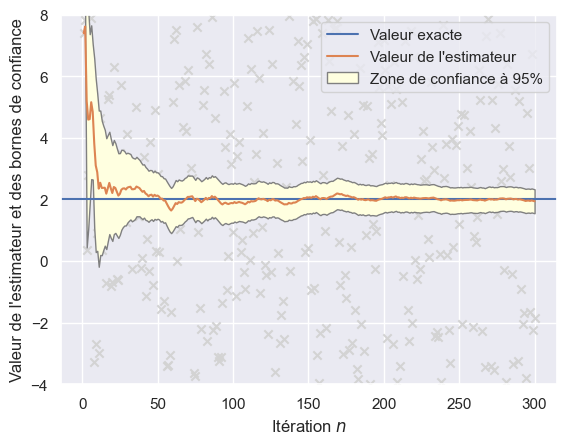

In [2]:
N = 300
sample = rng.uniform(size = N, low = -4, high = 8)

n = np.arange(1, N+1)
mn = np.cumsum(sample) / n
sum_squares = np.cumsum(sample**2)
# attention: les vecteurs vn, ic, upper et lower sont définis pour n >= 2
vn = (sum_squares - n*mn**2)[1:] / (n[1:]-1)  # on développe le carré
ci_size = 1.96*np.sqrt(vn / n[1:])
upper = mn[1:] + ci_size
lower = mn[1:] - ci_size

fig, ax = plt.subplots()
ax.scatter(n, sample, marker="x", color='lightgrey')
ax.axhline(y=2, color='C0', label="Valeur exacte")
ax.plot(n, mn, color='C1', label="Valeur de l'estimateur")
ax.fill_between(n[1:], lower, upper, facecolor='lightyellow', 
                edgecolor='grey', label="Zone de confiance à 95%")
ax.set(xlabel = "Itération $n$", 
       ylabel = "Valeur de l'estimateur et des bornes de confiance")
ax.legend(loc='upper right')
ax.set_ylim(-4, 8)
#plt.savefig('img/tcl_unif.png')
plt.show()

### Question: LFGN loi de Cauchy

Reprendre rapidement l'exemple précédent en remplaçant la loi uniforme par la loi de Cauchy. On obtient des réalisations de la loi de Cauchy en utilisant la méthode `standard_cauchy` de l'objet `rng`. Répliquer plusieurs fois le tracé (avec l'axe des ordonnées restreint à $[-10,10]$) pour différentes valeurs de $n=100\,000$. Qu'en pensez-vous? 

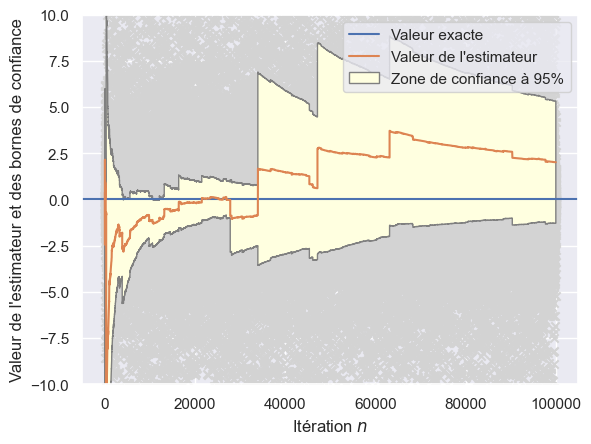

In [3]:
N = 100000
sample = rng.standard_cauchy(size = N)

n = np.arange(1, N+1)
mn = np.cumsum(sample) / n
sum_squares = np.cumsum(sample**2)
# attention: les vecteurs vn, ic, upper et lower sont définis pour n >= 2
vn = (sum_squares - n*mn**2)[1:] / (n[1:]-1)
ci_size = 1.96*np.sqrt(vn / n[1:])
upper = mn[1:] + ci_size
lower = mn[1:] - ci_size

fig, ax = plt.subplots()
ax.scatter(n, sample, marker="x", color='lightgrey')
ax.axhline(y=0, color='C0', label="Valeur exacte")
ax.plot(n, mn, color='C1', label="Valeur de l'estimateur")
ax.fill_between(n[1:], lower, upper, facecolor='lightyellow', 
                edgecolor='grey', label="Zone de confiance à 95%")
ax.set(xlabel = "Itération $n$", 
       ylabel = "Valeur de l'estimateur et des bornes de confiance")
ax.legend(loc='upper right')
ax.set_ylim((-10,10))
plt.show()

## Illustration du TCL 

On veut illustrer la répartition de l'erreur renormalisée $\displaystyle \varepsilon_n = \sqrt{n} \Bigl(\frac{m_n - m}{\sigma_n}\Bigr)$ pour différentes valeurs de $n$. Lorsque $n$ est grand cette erreur renormalisée est proche de la loi normale cenrée réduite, c'est ce qu'on veut vérifier numériquement. 
Pour illustrer cette répartition, il est nécessaire de répliquer un grand nombre de fois l'erreur c'est à dire de considérer un échantillon $(\varepsilon_n^{(j)})_{j=1,\dots,M}$ de taille $M$ et de constuire l'histogramme de cet échantillon.

**Attention:** en pratique il n'est pas nécessaire de répliquer $M$ fois l'estimateur $m_n$ pour approcher $m$. L'estimateur de la variance $v_n$ suffit pour donner la zone de confiance autour de $m_n$. C'est une information importante donnée par le TCL.

### Question: TCL loi uniforme 

Dans le cas de la loi uniforme sur $[-4, 8]$ vérifier la répartition de l'erreur renormalisée $\varepsilon_n$ pour $n = 10$ puis $n = 1\,000$ à partir d'un échantillon de taille $M = 100\,000$.

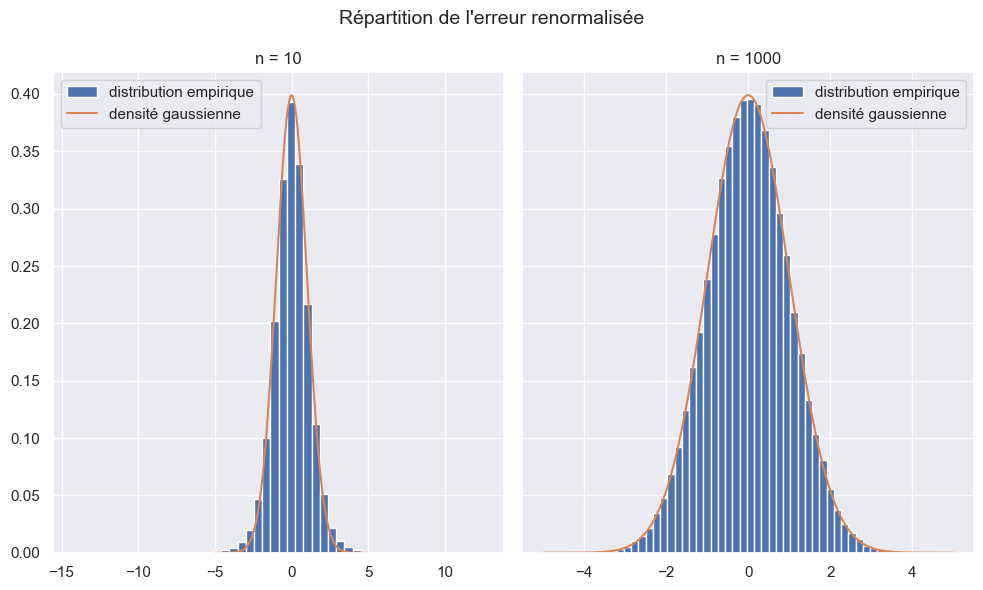

In [4]:
def plot_error(ax, n, M = 100000):
    sample = rng.uniform(size = (M, n), low = -4, high = 8)

    means = np.mean(sample, axis = 1) 
    sigms = np.std(sample, axis = 1, ddof=1)
    errs = np.sqrt(n) * (means - 2) / sigms 

    ax.hist(errs, bins=50, density=True, label="distribution empirique")
    xx = np.linspace(-5, 5, 10000)
    ax.plot(xx, stats.norm.pdf(xx), label="densité gaussienne")
    ax.set(title = f"n = {n}")
    ax.legend()
    return ax

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=True, 
                               figsize=(10,6), layout='tight')
fig.suptitle("Répartition de l'erreur renormalisée", fontsize=14)
plot_error(ax1, n=10)
plot_error(ax2, n=1000)
plt.show()
# pour N = 10 la répartition de l'erreur ne semble pas vraiment gaussienne
# pour N = 1000 le comportement semble gaussien

## Un premier exemple d'estimateur de Monte Carlo

On va mettre en oeuvre un estimateur de Monte Carlo pour calculer

$$
  I(\beta) = \mathbf{E}[\exp(\beta G)] \quad 
  \text{où $G \sim \mathcal{N}(0,1)$ et $\beta \in \mathbf{R}$}. 
$$

La valeur exacte $I(\beta) = \exp(\beta^2/2)$ est connue mais cet exemple permet d'illustrer l'importance des bornes de l'intervalle de confiance (et donc de l'estimation de la variance) dans une méthode de Monte Carlo. La seule valeur moyenne $I_n = \frac{1}{n} \sum_{k=1}^n X_k$ n'est pas suffisante pour déterminer $I$.

### Question: fonction `monte_carlo`

Ecrire une fonction `monte_carlo(sample, proba=0.95)` qui à partir d'un échantillon `sample` de réalisation indépendantes $(X_k)_{k=1,\dots,n}$ renvoie un tuple qui contient: 

- la moyenne de l'estimateur Monte Carlo de $I = \mathbf{E}[X]$,
- l'estimateur de la variance asymptotique apparaissant dans le TCL,
- les bornes inférieures et supérieures de l'intervale de confiance de niveau de probabilité `proba`.

In [5]:
def monte_carlo(sample, proba = 0.95):
    """
    Computes the mean, variance, and a 95% confidence interval of a 
    given sample data set using the Monte Carlo method.
    Parameters:
    -----------
    sample : array-like
        The data set to be analyzed
    proba : float, optional
        The probability that the true mean of the population is 
        within the calculated interval. Default is 0.95
    Returns:
    --------
    tuple : float
        The mean, variance, lower bound of the 95% CI and upper bound of the 95% CI
    """
    mean = np.mean(sample)
    var = np.var(sample, ddof=1)
    alpha = 1 - proba 
    quantile = stats.norm.ppf(1 - alpha/2)  # fonction quantile 
    ci_size = quantile * np.sqrt(var / sample.size)
    return {
        "mean": mean, 
        "var": var, 
        "lower": mean - ci_size, 
        "upper": mean + ci_size
    }
    #return (mean, var, mean - ci_size, mean + ci_size)

### Question: premier exemple

En utilisant la fonction `monte_carlo`, reproduire le tableau suivant où chaque ligne représente un résultat pour une valeur de $\beta \in \{0.2, 0.5, 1, 2, 3, 5\}$: 

- la première colonne est la valeur moyenne $I_n$,
- la deuxième colonne l'estimateur de la variance,
- les colonnes 3 et 4 sont les bornes inférieures et supérieurs de l'IC à 95%,
- la colonne 5 contient la valeur exacte $\mathbf{E}[\exp(\beta G)] = \exp(\beta^2/2)$.

Ce tableau est obtenu pour $n = 1\,000\,000$. Comment interpréter ce tableau? 

In [6]:
import pandas as pd
df = pd.read_pickle("data/first_df.pkl")
df

,mean,var,low,high,exact
0.2,1.020551,4.245536e-02,1.020147,1.020955,1.020201
0.5,1.134027,3.650418e-01,1.132843,1.135212,1.133148
1.0,1.651060,4.676691e+00,1.646821,1.655298,1.648721
2.0,7.402685,2.379946e+03,7.307068,7.498301,7.389056
3.0,87.915075,8.558333e+06,82.181273,93.648877,90.017131
5.0,121963.825619,6.439313e+14,72228.169429,171699.481809,268337.286521


In [7]:
n = int(1e6)
sample = rng.standard_normal(size=n)

betas = [0.2, 0.5, 1, 2, 3, 5]
result = [ monte_carlo(np.exp(beta * sample)) for beta in betas ]

# results est une liste de tuple on peut le convertir en DataFrame 
# pour manipuler plus facilement ce résultat 
import pandas as pd
res_df = pd.DataFrame(result, 
                      columns=["mean", "var", "lower", "upper"], 
                      index=betas)
res_df["exact"] = np.exp(0.5 * np.array(betas)**2)
res_df
#res_df.to_pickle("data/first_df.pkl")  

,mean,var,lower,upper,exact
0.2,1.019915,4.251146e-02,1.019511,1.020319,1.020201
0.5,1.132479,3.652511e-01,1.131294,1.133663,1.133148
1.0,1.647759,4.681183e+00,1.643518,1.652000,1.648721
2.0,7.396289,2.636496e+03,7.295651,7.496927,7.389056
3.0,89.138017,1.533818e+07,81.462017,96.814018,90.017131
5.0,165252.929067,3.878368e+15,43193.151143,287312.706990,268337.286521


## Option panier: un exemple multidimensionnel

On considère $d \ge 2$ actifs financiers dont la loi à l'instant $T > 0$ est modélisée par une loi log-normale c'est à dire 
\begin{equation*}
    \forall i \in \{1,\dots,d\}, \quad
    S^i_T = S^i_0 \exp\Bigl( \bigl(r-\frac{\sigma_i^2}{2}\bigr) T + \sigma_i \sqrt{T} \tilde G_i \Bigr)
\end{equation*}
où le vecteur $(\tilde G_1,\dots, \tilde G_d)$ est gaussien centré de matrice de covariance $\Sigma$ et les constantes $r > 0$, $\sigma_i > 0$ sont fixées. Il s'agit d'actifs financiers $(S^i_t)_{t \in [0,T]}$, $1 \le i \le d$, modélisés par un processus de Black-Scholes multidimensionnel. On introduit la matrice $L$ triangulaire inférieure obtenue par la décomposition de Cholesky de la matrice $\Sigma = L L^\top$. 

A l'aide de cette matrice $L$, on définit la fonction $\Phi:\mathbf{R}^d \to \mathbf{R}^d$ telle que 
\begin{equation*}
    (S^1_T, \dots, S^d_T) = \Phi(G_1, \dots, G_d) \quad \text{ou encore} \quad S^i_T = \Phi_i(G_1, \dots, G_d)
\end{equation*}
où $(G_1, \dots, G_d) \sim \mathcal{N}(0, I_d)$ (l'égalité précédente est à considérer en loi).

On s'intéresse au prix d'une option européenne (aussi appelé produit dérivé européen) sur le panier de ces $d$ actifs financiers, c'est à dire qu'on veut calculer 
\begin{equation*}
    \mathbf{E} \bigl[ X \bigr] %\quad \text{avec} \quad g(x) = (x-K)_+ \quad \text{ou} \quad g(x) = (K-x)_+ 
    \quad \text{avec} \quad 
    X = \biggl(\frac{1}{d} \sum_{i=1}^d S^i_T  - K\biggr)_+.
\end{equation*}

### Question: initialisation 

Définir les paramètres globaux $d = 10$, $T = 1$, $r = 0.01$, $S^i_0 =100$ (pour tous les actifs), $\sigma_i = i / (2d)$ (on dit que certains actifs sont plus volatiles que d'autres) et la matrice de corrélation $\Sigma$ définie par $\Sigma_{i,i} = 1$ et $\Sigma_{i,j} = \rho \in [0,1]$ pour $i \neq j$, avec $\rho = 0.2$.

Initialiser la matrice $L$ en utilisant la fonction `np.linalg.cholesky`.

In [11]:
d = 10
T = 1
r = 0.01
S0 = np.full(d, 100)
sigma = np.arange(1,d+1)/(2*d)
mu = r - 0.5*sigma**2
rho = 0.2
correl = np.full((d,d), rho) + (1-rho)*np.eye(d) #ou np.diag(np.full(d, 1-rho))
mat_L = np.linalg.cholesky(correl)

In [12]:
correl

array([[1. , 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 1. , 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 1. , 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 1. , 0.2, 0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 1. , 0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2, 1. , 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 1. , 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 1. , 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 1. , 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 1. ]])

In [13]:
mat_L

array([[1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.2       , 0.9797959 , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.2       , 0.16329932, 0.96609178, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.2       , 0.16329932, 0.13801311, 0.95618289, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.2       , 0.16329932, 0.13801311, 0.11952286, 0.9486833 ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.2       , 0.16329932, 0.13801311, 0.11952286, 0.10540926,
        0.94280904, 0.        , 0.        , 0.        , 0.        ],
       [0.2       , 0.16329932, 0.13801311, 0.11952286, 0.10540926,
        0.0942809 , 0.93808315, 0.        , 0.        , 0.        ],
       [0.2       , 0.16329932, 0.1380131

### Question: simulation d'un échantillon d'actifs

Définir la fonction python `phi` qui transforme le vecteur $(G_1, \dots, G_d)$ en un vecteur $(S_T^1,\dots, S_T^d)$ (tous les paramètres sont des variables globales pour simplifier l'écriture du code). L'appel suivant doit fonctionner 
```
G = rng.standard_normal(size=d)
phi(G)
```
Si on veut implémenter un estimateur Monte Carlo il faut travailler avec des échantillons _i.i.d._ $(S^{(j)}_T)_{j=1,\dots,n}$ où $S^{(j)}_T = \big(S_T^{(j),1}, \dots, S_T^{(j),d}\big) \in \mathbf{R}^d$. Modifier votre fonction `phi` pour création un tel échantillon à partir de l'appel suivant: 
```
sample_G = rng.standard_normal(size=(d, n))
phi(sample_G)
```
(il faut utiliser la technique du broadcasting en `numpy`, c'est très important à connaitre en pratique).

In [14]:
# première version
def phi(G): 
    ST = S0 * np.exp(mu * T + sigma * np.sqrt(T) * mat_L @ G)
    return ST

G = rng.standard_normal(size=d)
print(phi(G))

# deuxième version pour obtenir un échantillon de taille `n`
def phi(sample_G): 
    sample_ST = S0[:,np.newaxis] * np.exp(mu[:,np.newaxis] * T 
                + sigma[:,np.newaxis] * np.sqrt(T) * mat_L @ sample_G)
    return sample_ST

n = 1000
sample_G = rng.standard_normal(size=(d, n))
print(phi(sample_G))

[100.08371475 116.17333953 140.05911369  92.36778047 102.73992594
  65.08890654 113.42440183  99.64079311  70.62603938 161.43417037]
[[108.66599934  96.25031308 110.06319968 ...  99.0937169  108.29719718
  109.96403182]
 [103.90691598 110.15752805 103.84158588 ...  93.51912781 113.84788509
  110.0242026 ]
 [ 78.35547474  91.62714862 122.72499603 ...  87.61071647 121.2718228
  105.30590879]
 ...
 [ 96.44719072  73.68389103  94.13258892 ... 152.74164559 107.51750385
  135.87642981]
 [ 32.62381453  33.40193876  85.20275394 ...  61.51557622 311.07708964
  101.63745188]
 [170.41591196  69.60820817 109.20990405 ...  90.81371251  80.59042776
  105.49755197]]


### Question: estimateur Monte Carlo 

Définir une fonction $\psi: \mathbf{R}^d \times \mathbf{R}_+ \to \mathbf{R}_+$ telle que
\begin{equation*}
  \psi(G_1, \dots, G_d, K) = 
  \biggl(\frac{1}{d} \sum_{i=1}^d \Phi_i(G_1, \dots, G_d) - K\biggr)_+
\end{equation*}
dans une fonction `python` appelée `psi`. Cette fonction doit fonctionner avec un échantillon $(G^{(j)}_1, \dots, G^{(j)}_d)_{j=1,\dots,n}$.  
Ecrire et programmer l'estimateur de Monte Carlo pour estimer la quantité $\mathbf{E}[X] = \mathbf{E}[\psi(G_1, \dots, G_d, K)]$ où $(G_1, \dots, G_d) \sim \mathcal{N}(0, I_d)$.  

Pour différentes valeur de $K \in \{80,90,100,110,120\}$ et $n = 100\,000$ vous devez obtenir le tableau suivant: 

In [15]:
import pandas as pd
df = pd.read_pickle("data/basket_mc.pkl")
df

,mean,var,lower,upper
80,21.394471,228.318772,21.300818,21.488123
90,12.860460,181.187947,12.777032,12.943889
100,6.655165,111.553749,6.589702,6.720627
110,2.998650,54.132985,2.953049,3.044252
120,1.204158,21.976278,1.175102,1.233213


In [25]:
def psi(sample_G, K): 
    return np.maximum(phi(sample_G).mean(axis=0) - K, 0)

n = int(1e6)
sample_G = rng.standard_normal(size=(d, n))
Ks = [80, 90, 100, 110, 120]
result = [ monte_carlo(psi(sample_G, K)) for K in Ks ]
df_mc = pd.DataFrame(result, index=Ks)
#df_mc = pd.DataFrame(result, 
#                         columns=['mean', 'var', 'lower', 'upper'], 
#                         index=Ks)
df_mc
#df_mc.to_pickle('data/basket_mc.pkl')

,mean,var,lower,upper
80,21.303890,228.154859,21.274285,21.333495
90,12.776736,181.047917,12.750364,12.803108
100,6.594640,111.543095,6.573940,6.615340
110,2.969353,54.423565,2.954894,2.983812
120,1.200447,22.437365,1.191163,1.209731


### Question: monte-carlo adaptatif 

Ecrire une fonction `monte_carlo_adaptive` pour calculer le prix à une précision $\epsilon > 0$ fixée (telle que la taille de l'IC à un niveau de confiance donné soit plus petite que $\epsilon$).

In [17]:
from time import time

In [26]:
def monte_carlo_adaptive(get_sample: callable, epsilon: float, 
                         batch_size: int=10000, proba: float=0.95):
    # on récupère un sample de taille batch_size
    sample = get_sample(batch_size) 

    start = time()
    # on fait une boucle en appelant monte_carlo pour atteindre epsilon (pas optimal)
    r_MC = monte_carlo(sample, proba)
    ci_range = r_MC["upper"] - r_MC["lower"]
    size = batch_size 
    while ci_range >= epsilon: 
        # attention l'approche n'est pas optimale: la complexité n'est plus linéaire !!! 
        sample = np.hstack([sample, get_sample(batch_size)]) # non optimal 
        r_MC = monte_carlo(sample, proba)  # car reutilisation de ce bout de code 
        ci_range = r_MC["upper"] - r_MC["lower"]
        size += batch_size  
    stop = time()
    
    result = r_MC
    result["size"] = size 
    result["time"] = stop - start
    
    return result

In [27]:
def get_payoffs_K(batch_size: int, K: float): 
    sample_G = rng.standard_normal(size=(d, batch_size))
    return psi(sample_G, K)

In [28]:
Ks = [80, 90, 100, 110, 120]
result = [ monte_carlo_adaptive(
            lambda size: get_payoffs_K(size, K),  # argument get_sample
            epsilon=0.01, batch_size=100000
            ) for K in Ks ]


In [29]:
pd.DataFrame(result, index=Ks)

,mean,var,lower,upper,size,time
80,21.298602,228.364732,21.293602,21.303601,35100000,24.682171
90,12.776653,181.060717,12.771660,12.781646,27900000,16.515140
100,6.591118,111.598646,6.586125,6.596110,17200000,8.081024
110,2.969548,54.450206,2.964557,2.974538,8400000,2.450883
120,1.196421,22.447703,1.191457,1.201385,3500000,0.657661


### Question: variables antithétiques 

Sur le même modèle que précédemment, implémenter la méthode de Monte Carlo avec réduction de variance par variables antithétiques c'est à dire basée sur la représentation: 
\begin{equation*}
    \mathbf{E}[X] = \mathbf{E} \Big[ \frac{1}{2} \bigl( \psi(G_1, \dots, G_d, K) + \psi(-G_1, \dots, -G_d, K) \bigr) \Big]
\end{equation*}
Calculer le ratio de variance (variance de la méthode naïve divisée par variance par variables antithétiques) pour les différentes valeurs de $K$.  
Que signifie ce ratio de variance?  


In [30]:
sample_G = rng.standard_normal(size=(d, n))
Ks = [80, 90, 100, 110, 120]
result = []
for K in Ks:
    sample = 0.5 * (psi(sample_G, K) + psi(-sample_G, K))
    result.append(monte_carlo(sample))
df_antith = pd.DataFrame(result, index=Ks)

In [31]:
# le ratio des variances pour les différentes valeurs de K
df_mc["var"] / df_antith["var"]

80     15.922708
90      6.957182
100     3.262194
110     2.385265
120     2.130627
Name: var, dtype: float64

## Option panier: une variable de contrôle 

Dans le cas de la dimension 1 ($d=1$), le prix est donnée par une formule fermée, on appelle cette formule la formule de Black-Scholes. Pour une option Basket (en dimension $d \ge 2$) on approche le prix par Monte Carlo mais on peut utiliser des approximations pour construire un problème unidimensionnel proche du produit Basket. Ces approximations servent de variables de contrôles: **on ne rajoute pas une erreur, on retire de la variance**.

On rappelle que, en posant $\mu_i = r - \frac{1}{2}\sigma_i^2$,
\begin{equation*}
    X = \biggl(\frac{1}{d} \sum_{i=1}^d S^i_0 e^{\mu_i T + \sigma_i \sqrt{T}  \tilde G_i}  - K\biggr)_+
\end{equation*}
et en introduisant $a^i_0 = \frac{S^i_0}{\sum_{j=1}^d S^j_0}$ (t.q. $\sum a^i_0 = 1$) et $\bar S_0 = \frac{1}{d} \sum_{i=1}^d S^i_0$ on a 
\begin{equation*}
    X = \biggl(\bar S_0 \sum_{i=1}^d a^i_0 e^{\mu_i T + \sigma_i \sqrt{T}  \tilde G_i}  - K\biggr)_+.
\end{equation*}
La variable de contrôle proposée est obtenue en échangeant l'exponentielle et la moyenne pondérée par les poids $\big(a^i_0\big)_{i=1,\dots,d}$:
\begin{equation*}
    Y = \bigl(\bar S_0 e^Z  - K\bigr)_+
    \quad \text{avec} \quad 
    Z = \sum_{i=1}^d a^i_0 \big(\mu_i T + \sigma_i \sqrt{T}  \tilde G_i\big) 
\end{equation*}
La variable aléatoire $Z$ suit une loi gaussienne $Z \sim \mathcal{N}(m T, s^2 T)$ avec
\begin{equation*}
    m = \sum_{i=1}^d a^i_0 \mu_i
    \quad \text{et} \quad
    s^2 = \sum_{j=1}^d \Big( \sum_{i=1}^d a^i_0 \sigma_i L_{ij} \Big)^2. 
\end{equation*}
Ainsi l'espérance de la variable de contrôle $Y$ est connue par la formule de Black-Scholes, car elle correspond au prix d'un call de strike $K$ d'un actif Black-Scholes de dimension 1, de valeur initiale $\bar S_0$, de taux $\rho = m+\frac{1}{2} s^2$ et de volatilité $s$ (à un facteur d'actualisation près... attention à ça). On a donc 
\begin{equation*}
    e^{-\rho T} \mathbf{E} \big[ Y \big] = P_{\text{BS}}\big(\bar S_0, \rho, s, T, K\big),
\end{equation*}
où 
\begin{equation*}
    P_{\text{BS}}\big(x, r, \sigma, T, K\big) = x F_{\mathcal{N}(0,1)}(d_1) - K e^{-r T} F_{\mathcal{N}(0,1)}(d_2),
\end{equation*}
avec $F_{\mathcal{N}(0,1)}$ est la fonction de répartition de la loi normale centrée réduite et  la notation 
\begin{equation*}
    d_1 = \frac{1}{\sigma \sqrt{T}} \Big( \log\big( \frac{x}{K} \big) 
    + \big(r + \frac{\sigma^2}{2}\big) T \Big)
    \quad \text{et} \quad
    d_2 = d_1 - \sigma \sqrt{T}
\end{equation*}

### Question: préliminaires pour la variable de contrôle

- Définir la fonction `price_call_BS` qui code la fonction $P_{\text{BS}}\big(x, r, \sigma, T, K\big)$ définie ci-dessus.
- Initialiser les paramètres $\bar S_0$, $(a^i_0)_{i=1,\dots,d}$, $m$, $s^2$ et $\rho$.
- Calculer $\mathbf{E}[Y]$ par la formule fermée.
- Calculer $\mathbf{E}[Y]$ par un estimateur Monte Carlo à partir de réalisations de $( G_1^{(j)}, \dots,  G_d^{(j)})$, $j \in \{1, \dots, n\}$.
- Vérifier que tout est cohérent.

In [21]:
def price_call_BS(x, r, sigma, T, K):
    d1 = (np.log(x / K) + T * (r + 0.5*sigma**2)) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return x * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d2)

In [22]:
barS0 = S0.mean()   # ou np.mean(S0) 
a = S0 / S0.sum()   # np.sum(S0)
m = (a * (r - 0.5*sigma**2)).sum()
s2 = (((a * sigma).T @ mat_L)**2).sum()
rho = m + 0.5*s2

In [23]:
s2

np.float64(0.022825000000000005)

In [32]:
K = 100

In [33]:
# calcul par formule fermée
Y_mean = np.exp(rho*T) * price_call_BS(barS0, rho, np.sqrt(s2), T=T, K=K)
print("True value:", Y_mean)

True value: 4.7166246434390695


In [34]:
# calcul par Monte Carlo
n = int(1e5)
sample_G = rng.standard_normal(size=(d, n))
Z = np.sum(a[:,None] * (m*T + sigma[:,None] * np.sqrt(T) * mat_L @ sample_G),
           axis = 0)
Y = np.maximum(S0.mean() * np.exp(Z) - K, 0) 
monte_carlo(Y)

{'mean': np.float64(4.715366150094408),
 'var': np.float64(72.98410535651907),
 'lower': np.float64(4.662416604742982),
 'upper': np.float64(4.768315695445835)}

### Question: MC avec variable de contrôle

Implémenter l'estimateur de Monte Carlo avec variable de contrôle pour le calcul de $\mathbf{E}[X]$ c'est à dire 
\begin{equation*}
    \mathbf{E}\big[ X \big] = \mathbf{E} \big[\psi(G_1,\dots,G_d,K) - (Y - \mathbf{E}[Y]) \big],
\end{equation*}
où $Y$ est la variable de contrôle introduite précédemment et $\mathbf{E}[Y]$ est calculée par la formule fermée.  
Comparer les ratios de variance pour les différentes valeurs de $K$.

In [35]:
Ks = [80, 90, 100, 110, 120]
result = []
for K in Ks:
    Z = np.sum(a[:,None] * (m*T + sigma[:,None]*np.sqrt(T)*mat_L@sample_G), 
               axis = 0)
    Y = np.maximum(S0.mean() * np.exp(Z) - K, 0) 
    Y_mean = np.exp(rho*T) * price_call_BS(barS0, rho, np.sqrt(s2), T=T, K=K)
    control_variate = Y - Y_mean # variable centrée 
    sample = psi(sample_G, K) - control_variate
    result.append(monte_carlo(sample))

#df_cv = pd.DataFrame(result, 
#                     columns=['mean', 'var', 'lower', 'upper'], 
#                     index=Ks)
df_cv = pd.DataFrame(result, index=Ks)

In [36]:
# le ratio des variances pour les différentes valeurs de K
df_mc["var"] / df_cv["var"]

80     35.048882
90     23.594268
100    14.064549
110     8.333556
120     5.065413
Name: var, dtype: float64